# <center>**Strategy Simulation & Backtesting**</center>

In this notebook, we evaluate the profitability of our LSTM's predictions using a simulated limit order book environment.

**Assumptions:**
- **Execution:** Market Orders (we are a Taker). We cross the spread to guarantee execution.
- **Pricing:** To buy, we pay the `Ask`. To sell, we receive the `Bid`.
- **Trading Fees:** We apply Binance's standard Taker Fee of **0.1%** per trade.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('dark_background')

### Data Loading & Alignment

The LSTM was trained on `test.parquet`, which was **Z-score normalized**. We cannot calculate dollar profit/loss using normalized prices (like `-0.5`). Therefore, we will load the raw, un-normalized `lob_data.parquet` and align it with our predictions using the `timestamp` column.

Additionally, because the LSTM used a sliding window of `T=50`, the first 49 ticks were skipped. We must account for this offset.

In [13]:
SEQ_LENGTH = 50

# Load normalized test data (to get the correct test timestamps)
test_df = pd.read_parquet('test.parquet')
aligned_test = test_df.iloc[SEQ_LENGTH - 1:].copy().reset_index()

# Load LSTM Predictions
preds_df = pd.read_parquet('lstm_predictions.parquet')
assert len(aligned_test) == len(preds_df), "Lengths do not match! Alignment failed."

# Load RAW un-normalized data to get actual prices
raw_df = pd.read_parquet('lob_data.parquet')

# Convert raw string timestamps to datetime to match test.parquet
raw_df['timestamp'] = pd.to_datetime(raw_df['timestamp'], format='ISO8601')

# Replace normalized features with RAW features by merging on timestamp
aligned_test = aligned_test[['timestamp']].merge(raw_df, on='timestamp', how='left')

# Merge predictions into the aligned dataframe
aligned_test['predicted_signal'] = preds_df['predicted_label']
aligned_test['true_signal'] = preds_df['true_label']

aligned_test.head()

,timestamp,bid1_price,bid1_qty,ask1_price,ask1_qty,bid2_price,bid2_qty,ask2_price,ask2_qty,bid3_price,...,bid19_price,bid19_qty,ask19_price,ask19_qty,bid20_price,bid20_qty,ask20_price,ask20_qty,predicted_signal,true_signal
0,2026-07-05 15:10:21.329646,62605.29,0.87069,62605.3,0.75715,62605.28,0.00034,62605.31,0.00061,62605.27,...,62601.44,0.00023,62609.58,0.00016,62601.11,0.14706,62609.93,0.00008,0,0
1,2026-07-05 15:10:21.429441,62605.29,0.89582,62605.3,0.75706,62605.28,0.00034,62605.31,0.00052,62605.27,...,62602.00,0.02418,62609.96,0.26359,62601.95,0.00008,62609.97,0.13446,0,0
2,2026-07-05 15:10:21.532678,62605.29,0.89463,62605.3,0.98244,62605.28,0.00034,62605.31,0.00061,62605.27,...,62602.01,0.00009,62609.95,0.26046,62602.00,0.02418,62609.96,0.00018,0,0
3,2026-07-05 15:10:21.629428,62605.29,0.99808,62605.3,1.07315,62605.28,0.00061,62605.31,0.00070,62605.27,...,62602.00,0.02418,62609.95,0.26064,62601.95,0.00008,62609.97,0.00008,0,0
4,2026-07-05 15:10:21.742116,62605.29,0.83935,62605.3,4.11839,62605.28,0.00097,62605.31,0.00034,62605.27,...,62601.95,0.00008,62609.58,0.00026,62601.44,0.00023,62609.93,0.00008,0,-1


### The Backtesting Engine

We will step through time. Our model predicts if the price will go UP (1), DOWN (-1), or STATIONARY (0) in the *next* tick.

- If it predicts **UP (1)**, we hold a LONG position.
- If it predicts **DOWN (-1)**, we hold a SHORT position.
- If it predicts **STATIONARY (0)**, we stay FLAT.

Every time we change our position, we execute a market order and pay the spread + Binance 0.1% fee.

In [15]:

# Strategy Parameters
INITIAL_CAPITAL = 10000.0
FEE_RATE = 0.001 # 0.1% Binance Taker Fee

# Variables to track state
capital = INITIAL_CAPITAL
position = 0  # 1 for Long, -1 for Short, 0 for Flat
inventory = 0.0 # Amount of asset held

# For logging
equity_curve = []
trades = 0

print("Running Simulation...")

for i in range(len(aligned_test) - 1):
    current_ask = aligned_test.loc[i, 'ask1_price']
    current_bid = aligned_test.loc[i, 'bid1_price']
    
    # Current Equity Calculation (Mark to Market)
    if position == 1:
        current_equity = capital + (inventory * current_bid)
    elif position == -1:
        # For a short, inventory is negative, we buy back at the ask
        current_equity = capital + (inventory * current_ask)
    else:
        current_equity = capital
        
    equity_curve.append(current_equity)
    
    # The prediction is for the NEXT tick
    signal = aligned_test.loc[i, 'predicted_signal']
    
    # --- TRADING LOGIC ---
    # If signal says LONG, but we aren't long yet
    if signal == 1 and position != 1:
        # If we are short, close the short first
        if position == -1:
            cost_to_close = abs(inventory) * current_ask
            fee = cost_to_close * FEE_RATE
            capital -= (cost_to_close + fee)
            inventory = 0.0
            trades += 1
            
        # Open Long (Go all in with available capital)
        invest_amount = current_equity * 0.99 # Keep 1% buffer for fees
        inventory = invest_amount / current_ask
        fee = invest_amount * FEE_RATE
        capital -= (invest_amount + fee)
        position = 1
        trades += 1
        
    # If signal says SHORT, but we aren't short yet
    elif signal == -1 and position != -1:
        # If we are long, close the long first
        if position == 1:
            revenue = inventory * current_bid
            fee = revenue * FEE_RATE
            capital += (revenue - fee)
            inventory = 0.0
            trades += 1
            
        # Open Short (Short sell value equal to equity)
        short_amount = current_equity * 0.99
        inventory = -(short_amount / current_bid)
        fee = short_amount * FEE_RATE
        capital += (short_amount - fee)
        position = -1
        trades += 1
        
    # If signal says FLAT, close everything
    elif signal == 0 and position != 0:
        if position == 1:
            revenue = inventory * current_bid
            fee = revenue * FEE_RATE
            capital += (revenue - fee)
        elif position == -1:
            cost_to_close = abs(inventory) * current_ask
            fee = cost_to_close * FEE_RATE
            capital -= (cost_to_close + fee)
            
        inventory = 0.0
        position = 0
        trades += 1

# Append final equity for the last tick to match array lengths
equity_curve.append(current_equity)
aligned_test['Strategy_Equity'] = equity_curve

print("Simulation Complete!")

Running Simulation...
Simulation Complete!


### Performance & Analytics
We evaluate the strategy against a simple Buy & Hold benchmark. 

*Note: If the model predicted 0 trades, the Strategy Return will be 0.0%. This is common with imbalanced datasets unless class weights are applied during training.*

=== BACKTEST RESULTS ===
Total Trades Executed : 3,090
Strategy Return       : -95.24%
Buy & Hold Return     : 0.14%
Max Drawdown          : -95.24%


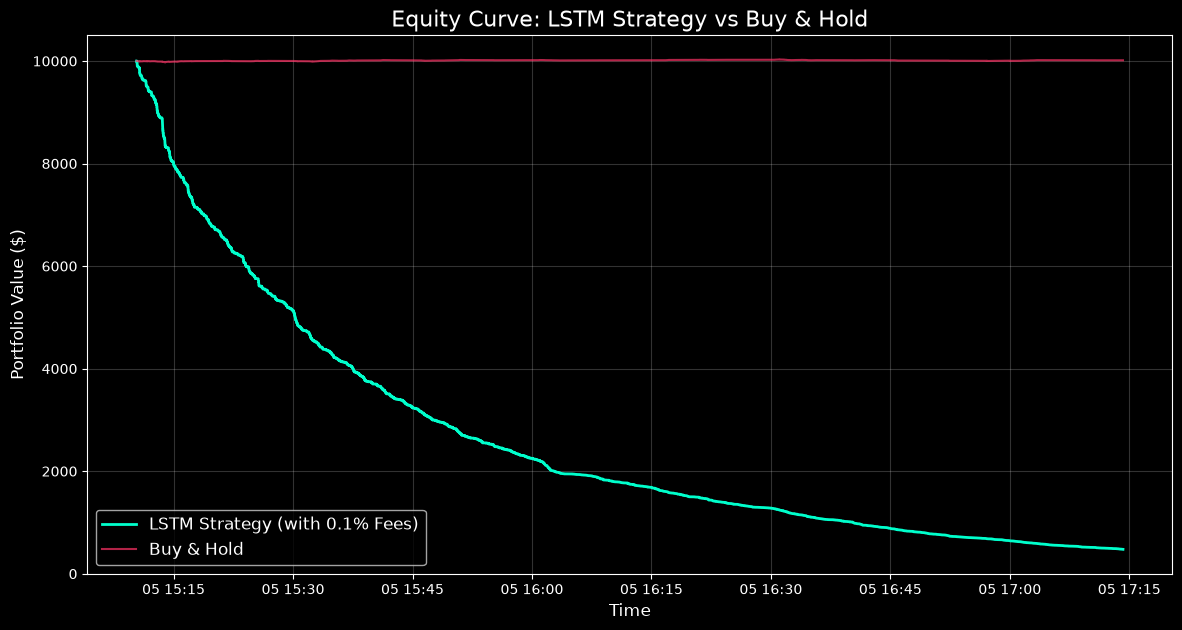

In [16]:
# Calculate Buy & Hold Equity (for comparison)
first_ask = aligned_test['ask1_price'].iloc[0]
aligned_test['Buy_Hold_Equity'] = (INITIAL_CAPITAL / first_ask) * aligned_test['bid1_price']

# --- Metrics ---
total_return_strategy = (aligned_test['Strategy_Equity'].iloc[-1] - INITIAL_CAPITAL) / INITIAL_CAPITAL
total_return_bh = (aligned_test['Buy_Hold_Equity'].iloc[-1] - INITIAL_CAPITAL) / INITIAL_CAPITAL

# Max Drawdown
aligned_test['Peak'] = aligned_test['Strategy_Equity'].cummax()
aligned_test['Drawdown'] = (aligned_test['Strategy_Equity'] - aligned_test['Peak']) / aligned_test['Peak']
max_drawdown = aligned_test['Drawdown'].min()

print("=== BACKTEST RESULTS ===")
print(f"Total Trades Executed : {trades:,}")
print(f"Strategy Return       : {total_return_strategy * 100:.2f}%")
print(f"Buy & Hold Return     : {total_return_bh * 100:.2f}%")
print(f"Max Drawdown          : {max_drawdown * 100:.2f}%")

# --- Plotting ---
plt.figure(figsize=(14, 7))
plt.plot(aligned_test['timestamp'], aligned_test['Strategy_Equity'], label='LSTM Strategy (with 0.1% Fees)', color='#00ffcc', linewidth=2)
plt.plot(aligned_test['timestamp'], aligned_test['Buy_Hold_Equity'], label='Buy & Hold', color='#ff3366', alpha=0.7, linewidth=1.5)
plt.title('Equity Curve: LSTM Strategy vs Buy & Hold', fontsize=16)
plt.ylabel('Portfolio Value ($)', fontsize=12)
plt.xlabel('Time', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.2)
plt.show()